# 第38课 · 把 N² 折成 N log N——蝶形（butterfly）分治，FFT 为何快数百倍

**目标**：理解 Cooley-Tukey 分治——偶/奇半 DFT + 蝶形合并 = 完整 DFT，复杂度从 $O(N^2)$ 到 $O(N\log N)$。

> **强制阅读路径（保护工作记忆）**：  
> ① 只看拆分树（不公式）→ ② 一对蝶形 E/O 的数字例子 → ③ 再读 $W$ 从哪来 → ④ 复杂度。  
> 位反转是实现细节，可标「L39 再用」。

🔗 **Aurora 连接**：`aurora.audio.transforms.fft()` 是迭代版 Cooley-Tukey（位反转 + 原地蝶形）；本课递归教「为什么」，实现 `butterfly()` 后你能读懂那个 while 循环。

← **上一课**　[L37 · DFT 暴力实现](L37_dft.ipynb)

> 上节课学习了 **DFT 暴力实现**：X[k]=Σ x[n]e^{-2πikn/N}，O(N²) 双循环 + numpy 对齐验证。  
> 本课将探讨 **FFT 蝶形分治**。

## 本课剧情：为什么 FFT 比暴力 DFT 快**数百倍**？

> 倍数随 $N$ 变：后文用 $N=4096$ 时约 $N^2/( \frac{N}{2}\log_2 N) \approx 682$ 倍；口说「几百倍」即可，不必死记 200。

想象你要在一个图书馆找到某本书的页码，暴力方法是逐页翻——O(N)。但如果书有索引，你先翻到对应字母，再在那一段里找——O(log N)。

DFT 的问题是：N 个频率 × N 个样本点 = **N² 次乘法**。对 N=4096 的音频帧，这是 1600 万次运算。

**Cooley-Tukey 的洞察**（1965）：

偶数下标的 DFT 和奇数下标的 DFT 各只有 N/2 点。把这两个"半结果"用蝶形（butterfly）合并，就能得到完整 N 点 DFT：

```
X[k]       = E[k] + W_N^k · O[k]      k = 0..N/2-1
X[k + N/2] = E[k] - W_N^k · O[k]      k = 0..N/2-1
```

这个分治可以**递归**：4096 → 2048 → 1024 → ... → 1。  
总层数 = log₂N，每层 N/2 次乘法 → 总计 **(N/2)·log₂N** 次。

N=4096 时：FFT 约 24576 次，DFT 约 1677 万次——**快了 682 倍**。

本节任务：实现 `butterfly(E, O)`——FFT 最小的可测试单元。


## 🤔 为什么工程师要发明它？(Why did engineers invent this?)

- **不用它会怎样？** 直接用 L37 的 O(N²) 暴力 DFT：一段 4096 点的音频帧要约 1600 万次乘法。语音流每几十毫秒就是一帧，实时处理时 CPU 直接跑不动。
- **它解决了什么真实问题？** 同一个 DFT 里藏着大量**被重复计算的半结果**。分治（divide & conquer）把这些半结果只算一次、再复用，就把 N² 折成了 N log N。
- **后面哪里还会再用到？** L39 递归实现整只 FFT、L41 加窗 FFT、**L43–L44 的 STFT 每一帧都要调用它**——它是整条音频特征流水线的地基。

## ⚠️ 常见误解 (Common Pitfall)

> 不要把 FFT 理解成"一种新的数学 / 新的变换"。它算出来的结果和 DFT **一模一样**——同一张频谱，一个复数都不差。FFT 只是把这个 DFT **更聪明地算**：先按偶 / 奇拆两半、复用中间的"半结果"，省掉重复乘法。换句话说，FFT 是一个**算法技巧**，不是一个新的数学对象。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

## 定位图：N=8 蝶形网络全貌

先看整体结构，再读公式推导。图中每条彩色 **X** 是一个蝶形单元；三层颜色对应三次递归合并（红→蓝→绿）；左侧输入按**位反转（bit reversal）序**排列，右侧输出为自然序频谱 X[0..7]。

## 0.5 旋转因子的几何直觉与数学由来

在深入公式前，必须理解 **旋转因子**（twiddle factor）这个关键的概念。这不只是一个魔法公式，而是从 DFT 的数学定义里**逼出来的**。

### 旋转因子：从 DFT 定义来

你还记得 L37 的 DFT 定义吗？  

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i kn / N}$$

看起来每一项都有 $e^{-2\pi i kn / N}$。现在想象我们要把这个求和**按 n 的奇偶拆分**：

- **偶数项**（n = 2m）：$e^{-2\pi i k(2m) / N} = e^{-2\pi i km / (N/2)}$
- **奇数项**（n = 2m+1）：$e^{-2\pi i k(2m+1) / N} = e^{-2\pi i km / (N/2)} \cdot e^{-2\pi i k / N}$

看到了吗？**奇数项比偶数项多了一个因子 $e^{-2\pi i k / N}$**。这就是旋转因子的来处。我们把它单独写出来：

$$W_N^k := e^{-2\pi i k / N}$$

所以蝶形公式里的 $W_N^k \cdot O[k]$，其实是原 DFT 奇数项天然带的那个"旋转"——从数学推导里直接跳出来，不是凭空设计的。

### 为什么叫"旋转"因子？——复数乘法的几何含义

复数 $e^{i\theta} = \cos\theta + i\sin\theta$ 在复平面上是什么？它是**从原点出发的单位圆上的一个点**，与正实轴的夹角为 $\theta$。

当你用 $e^{i\theta}$ 去乘一个复数 $z$，几何上就是：

$$z' = e^{i\theta} \cdot z$$

**把 $z$ 旋转 $\theta$ 弧度，长度不变**（因为 $|e^{i\theta}| = 1$）。

在我们的情况下，$W_N^k = e^{-2\pi i k / N}$ 就是**顺时针旋转 $2\pi k / N$ 弧度**（负号表示顺时针）。当 $k$ 从 0 增加到 $N-1$ 时，旋转角从 0 逐渐增加到 $-2\pi$，正好绕原点转一圈。这就是 FFT 用"旋转因子"这个名字的原因。

### 关键性质：$W_N^{k+N/2} = -W_N^k$——为什么下半部分用减号？

这是一个至关重要的对称性，使得我们**不需要额外计算**就能得到下半频谱。让我们严格推导它。

$$W_N^{k+N/2} = e^{-2\pi i (k+N/2) / N}$$

把指数展开：

$$= e^{-2\pi i k / N} \cdot e^{-2\pi i (N/2) / N}$$

$$= e^{-2\pi i k / N} \cdot e^{-\pi i}$$

现在用欧拉公式 $e^{i\theta} = \cos\theta + i\sin\theta$，令 $\theta = -\pi$：

$$e^{-\pi i} = \cos(-\pi) + i\sin(-\pi) = -1 + 0i = -1$$

所以：

$$W_N^{k+N/2} = W_N^k \cdot (-1) = -W_N^k$$

**推导完毕**。这意味着旋转因子本身有一个 180 度的周期对称性：每隔 $N/2$ 个下标，值就翻号。利用这一点，我们可以聪明地用同一组 $W_N^k$（$k=0..N/2-1$）通过加减号就直接得到完整 $N$ 点频谱。



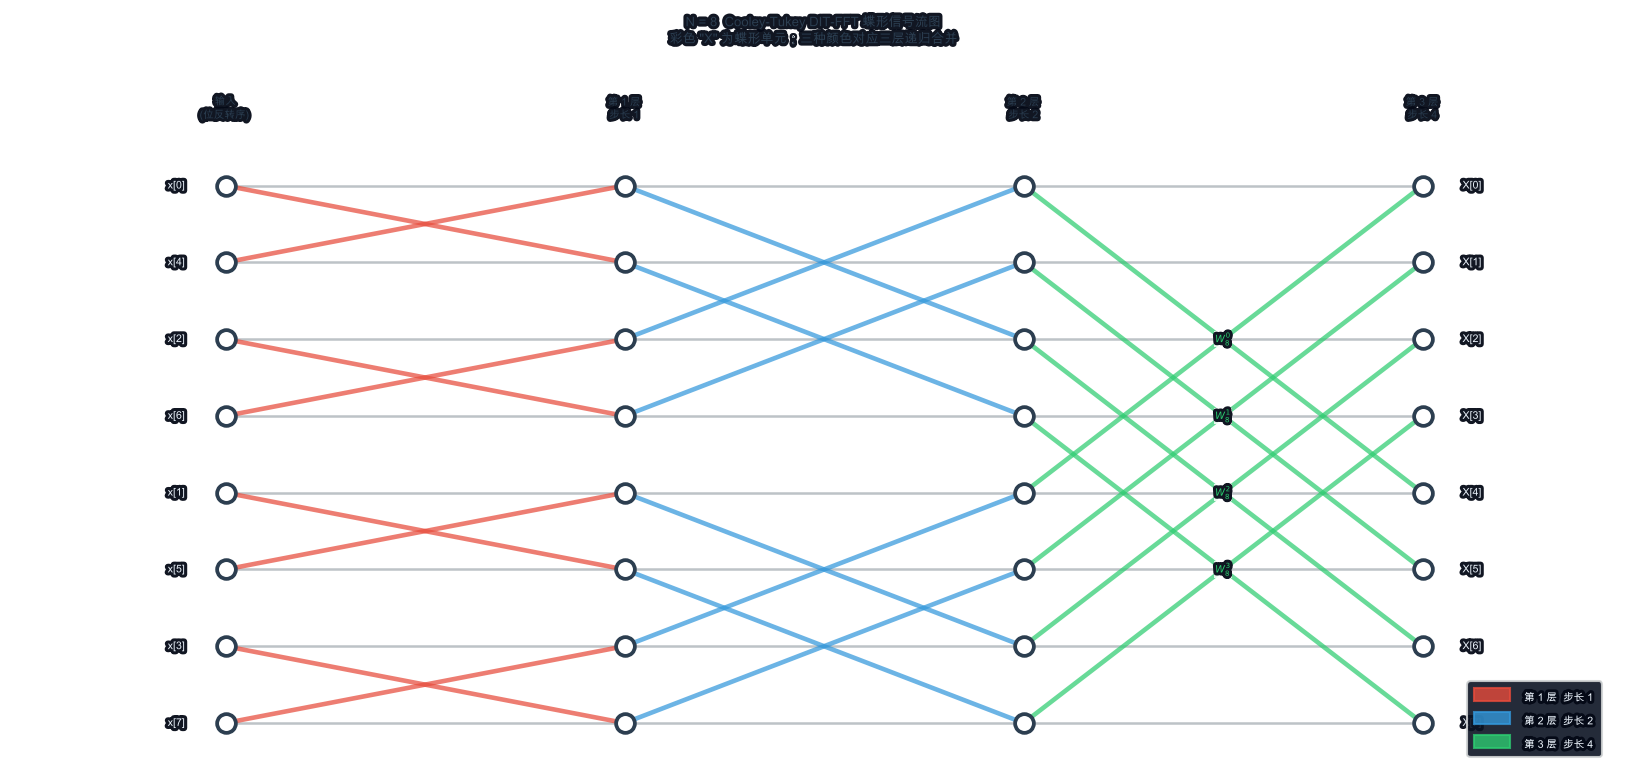

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5.5))

N = 8
n_stages = int(np.log2(N))  # = 3

xs = [0.0, 1.8, 3.6, 5.4]                  # x-coord for each column
ys = np.linspace(1.0, 0.0, N)              # y-coord: index 0 at top
COLORS = ['#e74c3c', '#3498db', '#2ecc71'] # red / blue / green per stage

# column headers
for x, lbl in zip(xs, ['输入\n(位反转序)', '第 1 层\n步长 1', '第 2 层\n步长 2', '第 3 层\n步长 4']):
    ax.text(x, 1.12, lbl, ha='center', va='bottom', fontsize=8.5,
            fontweight='bold', color='#2c3e50')

# butterfly connections
for stage in range(n_stages):
    stride = 2 ** stage
    color  = COLORS[stage]
    x_l, x_r = xs[stage], xs[stage + 1]
    for group in range(0, N, 2 * stride):
        for k in range(stride):
            u, v   = group + k, group + k + stride
            yu, yv = ys[u], ys[v]
            ax.plot([x_l, x_r], [yu, yu], '-', color='#bdc3c7', lw=1.2, zorder=1)
            ax.plot([x_l, x_r], [yv, yv], '-', color='#bdc3c7', lw=1.2, zorder=1)
            ax.plot([x_l, x_r], [yu, yv], '-', color=color, lw=2.2, alpha=0.72, zorder=2)
            ax.plot([x_l, x_r], [yv, yu], '-', color=color, lw=2.2, alpha=0.72, zorder=2)

# nodes
for x in xs:
    for i in range(N):
        ax.plot(x, ys[i], 'o', color='white', ms=9, mec='#2c3e50', mew=1.8, zorder=5)

# input (bit-reversed) / output labels
for i, br in enumerate([0, 4, 2, 6, 1, 5, 3, 7]):
    ax.text(xs[0]  - 0.18, ys[i], f'x[{br}]', ha='right', va='center', fontsize=8.5)
    ax.text(xs[-1] + 0.18, ys[i], f'X[{i}]',  ha='left',  va='center', fontsize=8.5)

# twiddle-factor labels on last stage
x_tw = (xs[2] + xs[3]) / 2
for k in range(4):
    y_mid = (ys[k] + ys[k + 4]) / 2
    ax.text(x_tw, y_mid, f'$W_8^{k}$', ha='center', va='center',
            fontsize=8, color=COLORS[2],
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1))

# legend
ax.legend(
    handles=[mpatches.Patch(color=c, alpha=0.8, label=f'第 {i+1} 层  步长 {2**i}')
             for i, c in enumerate(COLORS)],
    loc='lower right', fontsize=8.5, framealpha=0.9, edgecolor='#d0d3d4',
)

ax.set_xlim(-0.95, 6.25)
ax.set_ylim(-0.08, 1.25)
ax.axis('off')
ax.set_title('N = 8  Cooley-Tukey DIT-FFT 蝶形信号流图\n'
             '彩色 "X" 为蝶形单元；三种颜色对应三层递归合并',
             fontsize=10.5, fontweight='bold', pad=4, color='#2c3e50')
plt.tight_layout()
plt.show()

## 拆分示意：把一个 N=8 DFT 逐层对半砍成 8 个单点（先建立分治直觉）

上面的蝶形网络先记个印象就好。真正读懂公式前，只需要抓住一个画面：FFT 干的第一件事，就是**按偶 / 奇下标把序列一层层砍两半**，直到每段只剩 1 个点（单点 DFT = 它自己）：

```text
                DFT[0..7]   (N=8)
               /            \
        偶数下标            奇数下标
       [0 2 4 6]           [1 3 5 7]        ← 拆成 4 + 4
        /     \             /     \
     [0 4]   [2 6]       [1 5]   [3 7]      ← 拆成 2 + 2 + 2 + 2
      / \     / \         / \     / \
   [0][4] [2][6]       [1][5] [3][7]        ← 拆到 1，共 log₂8 = 3 层
```

向下是**拆分**（几乎不花钱，只是数组切片）；到底后再**逐层向上蝶形合并**，每层 N/2 次乘法。层数 log₂N × 每层 N/2 = 总计 (N/2)·log₂N 次乘法——这就是 O(N log N) 的来处。下面的分治公式，描述的正是"向上合并这一步"到底怎么算。

### 空间对应：递归树的"深度"和蝶形图的"左右位置"是怎么接上的？

刚才两张图看起来是完全不同的画法：

- **前面"定位图"那张三色蝶形信号流图**：从**左往右**画，画的是"数据流动顺序"——数据从左边输入，一路向右，最终变成频谱输出。三层颜色（红→蓝→绿）从左到右排列。
- **上面这棵递归树**：从**上往下**画，画的是"调用顺序"——先有一个大问题，再拆成两个小问题，再拆……一路拆到叶子。

这两张图讲的其实是**同一个计算过程**，只是坐标轴的意义完全不同，很容易看混。关键在于：**递归是"先一路拆到底，再从底往上合并"**——而"从底往上合并"发生的先后顺序，正好对应蝶形图"从左往右"的顺序。

拿 N=8 具体对齐一下：

| 合并动作 | 在递归里何时发生 | 对应蝶形图位置 |
|---|---|---|
| 把两个叶子（单点）合并成 2 点结果，比如 `[x0]` 和 `[x4]` → 2 点 DFT | **最先**完成（因为要先拆到最深，才能开始往回走） | **第 1 层**（信号流图最左边一列蝶形，紧贴输入，红色，步长 1） |
| 把两个 2 点结果合并成 4 点结果 | **中间**完成 | **第 2 层**（中间一列，蓝色，步长 2） |
| 把两个 4 点结果合并成最终的 8 点频谱 | **最后**完成（根节点最后返回） | **第 3 层**（信号流图最右边一列，紧贴输出，绿色，步长 4） |

记一句口诀：**"递归最先做完的合并，画在图的最左边；递归最后做完的合并，画在图的最右边。"** 原因是信号流图按"数据经过的先后顺序"从左往右画，而数据最先经过、最先被处理完的，正是离叶子最近、最先返回的那次合并。

光看文字表格可能还是绕——后面到"演示递归"那一格代码之后，我们会让程序亲口报告每次合并对应第几层，用实际运行结果验证这个对应关系。

## 1. 分治公式：偶奇拆分 + 蝶形合并

设 `x` 长度为 `N`，偶数下标子序列 `x_e = x[0,2,4,...]`，奇数下标子序列 `x_o = x[1,3,5,...]`，各长 `N/2`。令：

```
E[k] = DFT(x_e)[k]    k = 0..N/2-1
O[k] = DFT(x_o)[k]    k = 0..N/2-1
W_N^k = exp(-2πi·k/N)       # 旋转因子（twiddle factor）
```

则完整 N 点 DFT 为：

```
X[k]       = E[k] + W_N^k · O[k]      k = 0..N/2-1
X[k + N/2] = E[k] - W_N^k · O[k]      k = 0..N/2-1
```

上半 `X[0..N/2-1]` 加旋转因子，下半 `X[N/2..N-1]` 减——因为 `W_N^(k+N/2) = -W_N^k`，符号自动翻转，不需要额外计算。

In [4]:
# 验证分治公式：手动对 N=4 信号拆偶奇再合并
x = np.array([1, 2, 3, 4], dtype=complex)
N = len(x)

x_e = x[::2]   # [1, 3]
x_o = x[1::2]  # [2, 4]

E = np.fft.fft(x_e)  # 2点DFT
O = np.fft.fft(x_o)  # 2点DFT

k = np.arange(N // 2)
twiddles = np.exp(-2j * np.pi * k / N)  # W_N^k

X_top    = E + twiddles * O
X_bottom = E - twiddles * O
X_manual = np.concatenate([X_top, X_bottom])

X_ref = np.fft.fft(x)
print('手动分治结果 :', np.round(X_manual, 4))
print('numpy.fft 结果:', np.round(X_ref,    4))
print('完全吻合     :', np.allclose(X_manual, X_ref))

手动分治结果 : [10.+0.j -2.+2.j -2.+0.j -2.-2.j]
numpy.fft 结果: [10.+0.j -2.+2.j -2.+0.j -2.-2.j]
完全吻合     : True


## 1.5 蝶形公式从何而来？——从 DFT 定义推导

现在让我们看清那个分治公式 $X[k] = E[k] + W_N^k \cdot O[k]$ 到底怎么从原始 DFT 定义里推导出来的。这样你就不用背公式，而是理解它的来处。

给定 $x[0..N-1]$，DFT 定义说：

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i kn / N}$$

现在**按 n 的奇偶拆分这个求和**：

$$X[k] = \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k(2m) / N} + \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k(2m+1) / N}$$

对第一项（偶数项）：

$$\sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k(2m) / N} = \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i km / (N/2)}$$

这**正好是** $\text{DFT}(x_e)[k]$，即偶数下标子序列的 DFT，记作 $E[k]$。

对第二项（奇数项），把 $n=2m+1$ 代入指数：

$$\sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k(2m+1) / N}$$

$$= \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i km / (N/2)} \cdot e^{-2\pi i k / N}$$

$$= e^{-2\pi i k / N} \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i km / (N/2)}$$

$$= W_N^k \cdot \text{DFT}(x_o)[k] = W_N^k \cdot O[k]$$

所以：

$$X[k] = E[k] + W_N^k \cdot O[k]$$

**这个公式不是凭空设计的，而是从 DFT 的定义直接推导出来的！** 每当你看到它，其实就是在用奇偶拆分的性质。

现在你也理解了为什么**必须按奇偶分割**：因为 DFT 的指数 $e^{-2\pi i kn/N}$ 对偶数 $n$ 和奇数 $n$ 恰好分别满足 $e^{-2\pi i km/(N/2)}$ 的两种形式，奇偶分割就是在利用这个数学结构。其他任意分割方法都破坏了这个结构，就无法简化出蝶形公式。



## 2. 一次蝶形：2 输入 → 2 输出，复杂度为何是 O(N log N)

**蝶形（butterfly）** 指对一对复数 `(a, b)` 做：

```
top    = a + W · b
bottom = a - W · b
```

只需 1 次复数乘（`W·b`）和 2 次复数加减，输出 2 个结果。画在信号流图（signal flow graph）上，两条线交叉如蝴蝶翅膀，名字由此而来。

N 点 FFT 的层次结构：

```
层数    = log₂N
每层蝶形 = N/2 个
总蝶形  = (N/2) · log₂N
```

对比朴素 DFT 的 `N²` 次乘法：`N=1024` 时 FFT 只需约 5120 次，朴素需要 1048576 次，快了 200 倍。

In [5]:
# 比较朴素 DFT 与 FFT 的操作数（理论值）
for n_exp in [4, 8, 10, 12]:
    N = 2 ** n_exp
    naive_mults = N * N
    fft_butterflies = (N // 2) * n_exp  # 每个蝶形1次乘
    ratio = naive_mults / fft_butterflies
    print(f'N={N:5d}: 朴素={naive_mults:8d}  FFT蝶形={fft_butterflies:5d}  加速比={ratio:.1f}x')

N=   16: 朴素=     256  FFT蝶形=   32  加速比=8.0x
N=  256: 朴素=   65536  FFT蝶形= 1024  加速比=64.0x
N= 1024: 朴素= 1048576  FFT蝶形= 5120  加速比=204.8x
N= 4096: 朴素=16777216  FFT蝶形=24576  加速比=682.7x


## 3. 终止条件：N=1 时 DFT(x) = x

递归的最底层：当序列只有 1 个样本 `x[0]` 时，DFT 定义为：

```
X[0] = sum_{n=0}^{0} x[n] · exp(-2πi·0·0/1) = x[0] · 1 = x[0]
```

单点信号没有任何频率结构，DFT 输出就是输入本身。这是递归的基础情形，不需要任何乘法。

每层向上合并时，两个 `N/2` 点的结果通过蝶形合并成 `N` 点结果，直到最顶层得到完整 `X[0..N-1]`。

### 隐藏的前提：N 必须是 2 的幂次

上面说"一直拆到 N=1"，听起来理所当然——但这里悄悄藏了一个条件：**N 必须是 2 的正整数次幂**（即 N ∈ {1, 2, 4, 8, 16, 32, ...}）。

为什么这条件是必须的？想一想 N=6 会发生什么：

- 第一次拆分：`x[::2]` 长度 3，`x[1::2]` 长度 3——因为 6 是偶数，这一步还能对半砍。
- 但下一层，长度为 3 的序列再对半砍：`x[::2]` 长度 2，`x[1::2]` 长度 1——**两半长度不相等了**！

蝶形合并 `X[k] = E[k] ± W_N^k · O[k]` 要求 `E` 和 `O` 长度一样（这样才能一一配对做加减），一旦长度不等，递归就无法继续按同样的规则拆下去——要么直接报错，要么（更危险）NumPy 的广播规则"看似能算"却算出完全错误的结果。

课程后面所有例子（N=2, 4, 8）都精心选了 2 的幂次，这不是巧合，而是算法本身的硬性要求。真实录音信号长度几乎不会天生是 2 的幂次（比如 44100 点），标准做法是**补零（zero-padding）到最近的 2 的幂次**再做 FFT，这个技巧会在后面课程详细讲解。下面我们会用代码亲眼验证 N=6 究竟会怎样出错。

In [6]:
# 演示递归：手写极简递归 FFT（仅教学用，不优化）
def fft_recursive_demo(x):
    N = len(x)
    if N == 1:
        return x.copy()  # 终止条件
    E = fft_recursive_demo(x[::2])   # 偶数下标
    O = fft_recursive_demo(x[1::2])  # 奇数下标
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)
    return np.concatenate([E + W * O, E - W * O])

x_test = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=complex)
result = fft_recursive_demo(x_test)
print('递归FFT  :', np.round(result, 3))
print('numpy.fft:', np.round(np.fft.fft(x_test), 3))
print('吻合     :', np.allclose(result, np.fft.fft(x_test)))

递归FFT  : [36.+0.j    -4.+9.657j -4.+4.j    -4.+1.657j -4.+0.j    -4.-1.657j
 -4.-4.j    -4.-9.657j]
numpy.fft: [36.+0.j    -4.+9.657j -4.+4.j    -4.+1.657j -4.+0.j    -4.-1.657j
 -4.-4.j    -4.-9.657j]
吻合     : True


### 实证：让代码亲口报告每次合并对应蝶形图第几层

回到最前面"定位图"那张三色蝶形信号流图，它按**左→右**画了三层（红=第1层步长1，蓝=第2层步长2，绿=第3层步长4）。而"拆分示意"那张递归树按**上→下**画拆分。这两张图坐标系完全不同，容易看混——那句口诀是：

> **递归最先算完的合并，画在信号流图最左边；递归最后算完的合并，画在信号流图最右边。**

光说不算数，下面给 `fft_recursive_demo` 加一个"广播员"：每次执行完一次蝶形合并，就报告自己的递归深度、子问题规模，以及**这次合并对应蝶形图第几层**。跑起来看看，验证是不是真的和口诀说的一样：

In [7]:
# 带"广播员"的递归 FFT：每次合并都报告自己对应蝶形图第几层
def fft_trace(x, depth=0, total_depth=None):
    if total_depth is None:
        total_depth = int(np.log2(len(x)))  # 整个信号一共要拆 log2(N) 层
    N = len(x)
    if N == 1:
        return x.copy()

    E = fft_trace(x[::2], depth + 1, total_depth)   # 先递归到底（拆分）
    O = fft_trace(x[1::2], depth + 1, total_depth)
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)

    # depth 越大（递归越深）越先执行合并 → stage 越小 → 越靠蝶形图左边
    stage = total_depth - depth
    stride = 2 ** (stage - 1)
    print(f'递归深度 d={depth}（子问题 N={N}）完成合并 → 对应蝶形图【第{stage}层，步长{stride}】')

    return np.concatenate([E + W * O, E - W * O])

print('执行顺序（自动打印，留意“第1层”总是最先出现，“第3层”最后才出现）：\n')
x_trace = np.arange(1, 9).astype(complex)
result_trace = fft_trace(x_trace)

print('\n与 numpy.fft.fft 吻合：', np.allclose(result_trace, np.fft.fft(x_trace)))

执行顺序（自动打印，留意“第1层”总是最先出现，“第3层”最后才出现）：

递归深度 d=2（子问题 N=2）完成合并 → 对应蝶形图【第1层，步长1】
递归深度 d=2（子问题 N=2）完成合并 → 对应蝶形图【第1层，步长1】
递归深度 d=1（子问题 N=4）完成合并 → 对应蝶形图【第2层，步长2】
递归深度 d=2（子问题 N=2）完成合并 → 对应蝶形图【第1层，步长1】
递归深度 d=2（子问题 N=2）完成合并 → 对应蝶形图【第1层，步长1】
递归深度 d=1（子问题 N=4）完成合并 → 对应蝶形图【第2层，步长2】
递归深度 d=0（子问题 N=8）完成合并 → 对应蝶形图【第3层，步长4】

与 numpy.fft.fft 吻合： True


### 亲眼看看：如果 N 不是 2 的幂次，会发生什么？

刚才说"N 必须是 2 的幂次"，光讲道理可能还是不放心。下面直接拿 `fft_recursive_demo` 喂一个 N=6 的信号（6 是偶数，但不是 2 的幂次），看看会不会出问题：

In [8]:
# 用 N=6（不是 2 的幂次）试探 fft_recursive_demo 会怎样出错
x_bad = np.arange(1, 7).astype(complex)  # N = 6
print("x_bad =", x_bad, " N =", len(x_bad), "（6 不是 2 的幂次）")

try:
    fft_recursive_demo(x_bad)
    print("竟然算完了？——那也大概率是错的，应该和 np.fft.fft 对不上")
except ValueError as e:
    print("\n❌ 报错了：", e)
    print("原因：递归拆分到某一层时，偶数组和奇数组长度不相等，")
    print("      蝶形合并 E ± W·O 要求两边一一配对，长度不等就没法对齐相加减。")
    print("\n结论：N 必须是 2 的幂次，否则递归拆到某一层必然拆不均匀。")

x_bad = [1.+0.j 2.+0.j 3.+0.j 4.+0.j 5.+0.j 6.+0.j]  N = 6 （6 不是 2 的幂次）

❌ 报错了： operands could not be broadcast together with shapes (3,) (4,) 
原因：递归拆分到某一层时，偶数组和奇数组长度不相等，
      蝶形合并 E ± W·O 要求两边一一配对，长度不等就没法对齐相加减。

结论：N 必须是 2 的幂次，否则递归拆到某一层必然拆不均匀。


## 附录 B · 递归版 vs 生产版迭代版（读即可）

本课和 L39 用“递归”讲 FFT，因为递归树最容易看清分治结构：

```text
FFT(N) → FFT(N/2 偶数下标) + FFT(N/2 奇数下标) → 蝶形合并
```

但 `aurora.audio.transforms.fft()` 的生产实现是**迭代式** Cooley-Tukey：

| 对照 | L39 `my_fft` | `aurora.audio.transforms.fft()` |
|---|---|---|
| 结构 | 递归拆偶/奇 | 位反转排列 + `while size <= n` 层序蝶形 |
| 优点 | 最适合理解分治树 | 无递归开销，适合生产代码 |
| 共同点 | 都使用同一个蝶形公式 | 都应与 `np.fft.fft` 数值对齐 |
| 验证 | notebook `assert_allclose` | `tests/audio/test_transforms.py` |

你现在不需要读完整源码，只要知道：

- L38 学“一个蝶形怎么合并”
- L39 学“递归怎么把很多蝶形串起来”
- Aurora 源码学“工程里如何把递归摊平成迭代循环”


## 附录 C · 位反转置换（bit reversal permutation）——从递归到迭代的桥梁

为什么 Aurora 的生产代码要做"位反转排列"？这个部分解释递归版和迭代版的等价性。

### 什么是位反转置换？

位反转置换指的是：**把数组下标用二进制表示，然后把二进制位从左右两端对称翻转，得到新的下标**。

#### 例子：N=8，下标的位反转

对于 N=8（需要 3 位来表示下标 0..7）：

| 原下标 | 二进制 | 位反转 | 新下标 |
|---|---|---|---|
| 0 | 000 | 000 | 0 |
| 1 | 001 | 100 | 4 |
| 2 | 010 | 010 | 2 |
| 3 | 011 | 110 | 6 |
| 4 | 100 | 001 | 1 |
| 5 | 101 | 101 | 5 |
| 6 | 110 | 011 | 3 |
| 7 | 111 | 111 | 7 |

所以位反转置换的结果是：把原数组 `x[0,1,2,3,4,5,6,7]` 重新排列成 `x[0,4,2,6,1,5,3,7]` 的顺序。**这正好是我们之前信号流图左侧输入的顺序！**

### 为什么需要位反转？

递归版本的 FFT：
1. **隐式地** 按奇偶不断拆分
2. 最后拆到 8 个单点（自动排列成位反转序）
3. 再逐层向上蝶形合并

迭代版本的 FFT：
1. **显式地** 先做一次位反转置换，把输入数组重新排成位反转序
2. 再用 `while size <= n` 循环，逐层做蝶形合并（模拟递归回溯的过程）

这两种方法算出来的频谱完全一样。迭代版避免了递归调用的栈开销，性能更好；递归版逻辑更清晰，适合学习。

### 位反转的 Python 实现

如果你想看 Aurora 源码里位反转是怎么写的：

```python
def _bit_reverse_permutation(x, n):
    """原地位反转置换"""
    i = 0
    for j in range(1, n):
        # 找到 j 的位反转下标 i
        if j < i:
            x[i], x[j] = x[j], x[i]
        k = n >> 1  # 从最高位开始
        while k <= i:
            i -= k
            k >>= 1  # 向右移一位
        i += k
    return x
```

这个算法通过位操作 (`>>` 右移，`&` 按位与）高效地计算位反转。不需要完全理解这个细节，只要知道：**"位反转置换"就是把数组下标按二进制位翻转后重新排列**。

### 递归版 ↔ 迭代版的等价性

| 递归版逻辑 | 迭代版逻辑 |
|---|---|
| 调用 `fft(x[::2])` 和 `fft(x[1::2])` | 位反转置换后，自动排成了"先偶后奇"的多层分组 |
| 递归返回后调用 `butterfly` 合并 | `while size` 循环展开递归，逐层做蝶形合并 |
| 递归深度 = log₂N，自动管理栈 | while 循环深度 = log₂N，显式管理循环变量 |
| 容易理解，容易验证 | 高效运行，适合生产代码 |

你在 L39 学完递归版 FFT 后，就能看懂 Aurora 源码中迭代版的 `while size <= n` 循环——它的每一次迭代对应递归回溯过程中的一层蝶形合并。



---
⬇️ **通关检验**：附录 B 已读；请完成下方 N=4 半步蝶形草稿后再进入主 TODO。


### 暖身：N=2 最小蝶形——从两个单点到两点 DFT

在做 N=4 的半步练习前，先看看**最小的蝶形**是什么样的。

想象你有两个单点信号 `x[0]` 和 `x[1]`。根据 DFT 的基础情形，单点的 DFT 就是它自己：
- `E[0] = DFT([x[0]]) = x[0]`（偶数组只有位置 0）
- `O[0] = DFT([x[1]]) = x[1]`（奇数组只有位置 0）

现在用蝶形合并这两个单点的 DFT，得到完整的 2 点 DFT：

$$X[0] = E[0] + W_2^0 \cdot O[0] = x[0] + 1 \cdot x[1] = x[0] + x[1]$$

$$X[1] = E[0] - W_2^0 \cdot O[0] = x[0] - 1 \cdot x[1] = x[0] - x[1]$$

其中 $W_2^0 = e^{-2\pi i \cdot 0 / 2} = 1$（旋转因子在 k=0 时总是 1）。

这就是最基础的蝶形单元。让我们验证它：



In [9]:
# N=2 最小蝶形验证
x_test = np.array([3, 5], dtype=complex)  # 任意两个复数
E_n2 = x_test[0:1]  # 偶数组：[x[0]] → DFT 就是 [x[0]]
O_n2 = x_test[1:2]  # 奇数组：[x[1]] → DFT 就是 [x[1]]

# 蝶形合并
X_manual = np.array([E_n2[0] + O_n2[0], E_n2[0] - O_n2[0]], dtype=complex)
X_ref = np.fft.fft(x_test)

print(f"输入: {x_test}")
print(f"E（偶数下标 DFT）: {E_n2}")
print(f"O（奇数下标 DFT）: {O_n2}")
print(f"蝶形合并结果: {X_manual}")
print(f"numpy.fft 参考: {X_ref}")
print(f"完全一致：{np.allclose(X_manual, X_ref)}")

输入: [3.+0.j 5.+0.j]
E（偶数下标 DFT）: [3.+0.j]
O（奇数下标 DFT）: [5.+0.j]
蝶形合并结果: [ 8.+0.j -2.+0.j]
numpy.fft 参考: [ 8.+0.j -2.+0.j]
完全一致：True


## 半步练习 · N=4 蝶形草稿（不替代主 TODO）

在实现 `butterfly(E, O)` 前，先用 N=4 做一次纸上草稿，**逐步手算每个中间值**。

给定：

```python
x = [1, 0, 1, 0]
x_even = [1, 1]  （下标 0, 2）
x_odd  = [0, 0]  （下标 1, 3）
```

### 步骤 1：计算偶数组的 DFT — E = DFT([1, 1])

用 DFT 定义 $E[k] = \sum_{m=0}^{1} x_e[m] \cdot e^{-2\pi i km / 2}$（这是一个 N=2 的 DFT）：

- **k=0**：$E[0] = 1 \cdot e^{0} + 1 \cdot e^{0} = 1 + 1 = 2$
- **k=1**：$E[1] = 1 \cdot e^{0} + 1 \cdot e^{-2\pi i \cdot 1 / 2} = 1 + 1 \cdot e^{-\pi i}$
  - 现在 $e^{-\pi i} = \cos(-\pi) + i\sin(-\pi) = -1$
  - 所以 $E[1] = 1 + 1 \cdot (-1) = 0$

**结果**：$E = [2, 0]$

### 步骤 2：计算奇数组的 DFT — O = DFT([0, 0])

用同样的 DFT 定义 $O[k] = \sum_{m=0}^{1} x_o[m] \cdot e^{-2\pi i km / 2}$：

- **k=0**：$O[0] = 0 \cdot e^{0} + 0 \cdot e^{0} = 0$
- **k=1**：$O[1] = 0 \cdot e^{0} + 0 \cdot e^{-\pi i} = 0$

**结果**：$O = [0, 0]$（全零信号的 DFT 当然还是全零）

### 步骤 3：计算旋转因子 — $W_4^k$，k=0..1

对 N=4，旋转因子是 $W_4^k = e^{-2\pi i k / 4}$：

- **k=0**：$W_4^0 = e^{0} = 1$
- **k=1**：$W_4^1 = e^{-2\pi i / 4} = e^{-\pi i / 2}$
  - 用欧拉公式：$e^{-\pi i/2} = \cos(-\pi/2) + i\sin(-\pi/2) = 0 - i = -i$

**结果**：$twiddle = [1, -i]$

### 步骤 4：蝶形合并 — $X[k] = E[k] \pm W_4^k \cdot O[k]$

上半部分（k=0..1）：
- $X[0] = E[0] + W_4^0 \cdot O[0] = 2 + 1 \cdot 0 = 2$
- $X[1] = E[1] + W_4^1 \cdot O[1] = 0 + (-i) \cdot 0 = 0$

下半部分（k+N/2=2..3）：
- $X[2] = E[0] - W_4^0 \cdot O[0] = 2 - 1 \cdot 0 = 2$
- $X[3] = E[1] - W_4^1 \cdot O[1] = 0 - (-i) \cdot 0 = 0$

**最终结果**：$X = [2, 0, 2, 0]$

现在运行下一格对答案，验证你的手算。

In [10]:
import numpy as np

x = np.array([1, 0, 1, 0], dtype=complex)
E = np.fft.fft(x[::2])
O = np.fft.fft(x[1::2])
k = np.arange(len(E))
twiddle = np.exp(-2j * np.pi * k / len(x))

top = E + twiddle * O
bottom = E - twiddle * O
X_half_step = np.concatenate([top, bottom])
X_ref = np.fft.fft(x)

print("E =", np.round(E, 4))
print("O =", np.round(O, 4))
print("twiddle =", np.round(twiddle, 4))
print("半步拼接结果 =", np.round(X_half_step, 4))
np.testing.assert_allclose(X_half_step, X_ref, atol=1e-12)
print("✅ N=4 半步蝶形与 np.fft.fft 完全一致")


E = [2.+0.j 0.+0.j]
O = [0.+0.j 0.+0.j]
twiddle = [1.+0.j 0.-1.j]
半步拼接结果 = [2.+0.j 0.+0.j 2.+0.j 0.+0.j]
✅ N=4 半步蝶形与 np.fft.fft 完全一致


### 非平凡例子：换一组数字，让 E 和 O 都不为零

上面的手算里 `O = [0, 0]`——两个数都恰好是零。这太巧了，容易让人怀疑："是不是我哪里算错了？还是奇数组的 DFT 天生就该是 0？"

不是巧合，是因为 `x = [1, 0, 1, 0]` 里奇数下标的两个值 `x[1], x[3]` 本来就都是 0，这是特意挑的"教学友好"输入（结果好看，公式验证起来干净），并不代表真实数据。换一组四个数字都不一样的信号，比如：

```python
x = [1, 2, 3, 4]
x_even = [1, 3]   （下标 0, 2）
x_odd  = [2, 4]   （下标 1, 3）
```

再手算一遍，这次 E 和 O 都不会是零。

**步骤 1：偶数组的 DFT — E = DFT([1, 3])**

- $E[0] = 1 \cdot e^0 + 3 \cdot e^0 = 1 + 3 = 4$
- $E[1] = 1 \cdot e^0 + 3 \cdot e^{-\pi i} = 1 + 3 \cdot (-1) = 1 - 3 = -2$

**结果**：$E = [4, -2]$

**步骤 2：奇数组的 DFT — O = DFT([2, 4])**

- $O[0] = 2 \cdot e^0 + 4 \cdot e^0 = 2 + 4 = 6$
- $O[1] = 2 \cdot e^0 + 4 \cdot e^{-\pi i} = 2 + 4 \cdot (-1) = 2 - 4 = -2$

**结果**：$O = [6, -2]$（这次两个值都不是零！）

**步骤 3：旋转因子**——和之前一样，N=4 时 $twiddle = [1, -i]$（推导见上面步骤 3，这里数值不变，因为旋转因子只跟 N 和 k 有关，跟输入信号的具体数值无关）。

**步骤 4：蝶形合并 — $X[k] = E[k] \pm W_4^k \cdot O[k]$**

上半部分（k=0..1）：
- $X[0] = E[0] + W_4^0 \cdot O[0] = 4 + 1 \cdot 6 = 10$
- $X[1] = E[1] + W_4^1 \cdot O[1] = -2 + (-i) \cdot (-2) = -2 + 2i$

下半部分（k+N/2=2..3）：
- $X[2] = E[0] - W_4^0 \cdot O[0] = 4 - 6 = -2$
- $X[3] = E[1] - W_4^1 \cdot O[1] = -2 - 2i$

**最终结果**：$X = [10,\ -2+2i,\ -2,\ -2-2i]$

这次每一步的加减乘都真正用上了非零数字，不再是"看起来对但其实没验证到乘法"的巧合情形。运行下一格核对答案：

In [11]:
x2 = np.array([1, 2, 3, 4], dtype=complex)
E2 = np.fft.fft(x2[::2])
O2 = np.fft.fft(x2[1::2])
k2 = np.arange(len(E2))
twiddle2 = np.exp(-2j * np.pi * k2 / len(x2))

top2 = E2 + twiddle2 * O2
bottom2 = E2 - twiddle2 * O2
X_nontrivial = np.concatenate([top2, bottom2])
X_ref2 = np.fft.fft(x2)

print("E =", np.round(E2, 4), " ← 都不是零")
print("O =", np.round(O2, 4), " ← 都不是零")
print("twiddle =", np.round(twiddle2, 4))
print("非平凡例子结果 =", np.round(X_nontrivial, 4))
np.testing.assert_allclose(X_nontrivial, X_ref2, atol=1e-12)
print("✅ 非平凡例子与 np.fft.fft 完全一致")

E = [ 4.+0.j -2.+0.j]  ← 都不是零
O = [ 6.+0.j -2.+0.j]  ← 都不是零
twiddle = [1.+0.j 0.-1.j]
非平凡例子结果 = [10.+0.j -2.+2.j -2.+0.j -2.-2.j]
✅ 非平凡例子与 np.fft.fft 完全一致


## 4. ✏️ 实现 `butterfly(E, O)`

**推理路线**：
1. `N = len(E) * 2`；旋转因子 `twiddles = exp(-2πi · arange(N/2) / N)`
2. `top = E + twiddles * O`（上半频谱 `X[0..N/2-1]`）
3. `bottom = E - twiddles * O`（下半频谱 `X[N/2..N-1]`）
4. 返回 `np.concatenate([top, bottom])`，shape `(N,)`

**参考输入输出**：
```python
E = np.fft.fft(np.array([1, 3], dtype=complex))  # 2点DFT of 偶数下标
O = np.fft.fft(np.array([2, 4], dtype=complex))  # 2点DFT of 奇数下标
# butterfly(E, O) ≈ np.fft.fft([1, 2, 3, 4])
# 即 [10+0j, -2+2j, -2+0j, -2-2j]
```

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


In [12]:
def butterfly(E: np.ndarray, O: np.ndarray) -> np.ndarray:
    """单层蝶形合并：两个 N/2 点 DFT → 一个 N 点 DFT。

    参数
    ----
    E : shape (N/2,) complex — 偶数下标子序列的 DFT
    O : shape (N/2,) complex — 奇数下标子序列的 DFT

    返回
    ----
    shape (N,) complex — 完整 N 点 DFT
    """
    half = len(E)
    N = half * 2

    # ✏️ TODO: 计算旋转因子 twiddles，shape (N/2,)
    raise NotImplementedError("TODO: 计算旋转因子 twiddles = exp(-2πi · arange(N/2) / N)")

    # ✏️ TODO: 蝶形上半：top = E + twiddles * O
    raise NotImplementedError("TODO: 蝶形上半 top = E + twiddles * O")

    # ✏️ TODO: 蝶形下半：bottom = E - twiddles * O
    raise NotImplementedError("TODO: 蝶形下半 bottom = E - twiddles * O")

    # ✏️ TODO: 拼接并返回，shape (N,)
    raise NotImplementedError("TODO: 拼接 top 和 bottom 并返回，shape (N,)")

### 调试示例：N=4 完整蝶形单步执行

在写代码前，先看一个完整的 N=4 例子，**逐行打印中间值**，确保理解向量化操作：



In [13]:
# 手动一步步演示 butterfly 的计算过程（N=4 例子）
print("=" * 60)
print("N=4 蝶形单步执行：从偶/奇两个 N/2=2 点 DFT 合并成 N=4 点 DFT")
print("=" * 60)

E = np.array([2.0, 0.0], dtype=complex)  # DFT([1,1])
O = np.array([0.0, 0.0], dtype=complex)  # DFT([0,0])
N = 4

print(f"\n1️⃣  输入：")
print(f"   E（偶数下标 DFT）= {E}")
print(f"   O（奇数下标 DFT）= {O}")

half = len(E)
k = np.arange(half)
print(f"\n2️⃣  计算旋转因子 W_4^k：")
print(f"   k 数组 = {k}")

twiddles = np.exp(-2j * np.pi * k / N)
print(f"   W_4^k = exp(-2πi·k/4) = {np.round(twiddles, 4)}")
print(f"   详解：")
print(f"     W_4^0 = e^0 = 1")
print(f"     W_4^1 = e^(-πi/2) = -i")

print(f"\n3️⃣  计算复数乘法 W_4^k · O[k]：")
twiddles_times_O = twiddles * O
print(f"   [1, -i] × [0, 0] = {twiddles_times_O}（因为 O 全零，结果也全零）")

print(f"\n4️⃣  蝶形上半部分 (top = E + W·O)：")
top = E + twiddles_times_O
print(f"   [2, 0] + [0, 0] = {top}")

print(f"\n5️⃣  蝶形下半部分 (bottom = E - W·O)：")
bottom = E - twiddles_times_O
print(f"   [2, 0] - [0, 0] = {bottom}")

print(f"\n6️⃣  拼接成 N 点 DFT：")
X_manual = np.concatenate([top, bottom])
print(f"   X = [top | bottom] = {X_manual}")

print(f"\n✅ 参考值（np.fft.fft([1,0,1,0])）：")
X_ref = np.fft.fft(np.array([1, 0, 1, 0], dtype=complex))
print(f"   {X_ref}")
print(f"\n完全匹配：{np.allclose(X_manual, X_ref)}")
print("=" * 60)


N=4 蝶形单步执行：从偶/奇两个 N/2=2 点 DFT 合并成 N=4 点 DFT

1️⃣  输入：
   E（偶数下标 DFT）= [2.+0.j 0.+0.j]
   O（奇数下标 DFT）= [0.+0.j 0.+0.j]

2️⃣  计算旋转因子 W_4^k：
   k 数组 = [0 1]
   W_4^k = exp(-2πi·k/4) = [1.+0.j 0.-1.j]
   详解：
     W_4^0 = e^0 = 1
     W_4^1 = e^(-πi/2) = -i

3️⃣  计算复数乘法 W_4^k · O[k]：
   [1, -i] × [0, 0] = [0.+0.j 0.+0.j]（因为 O 全零，结果也全零）

4️⃣  蝶形上半部分 (top = E + W·O)：
   [2, 0] + [0, 0] = [2.+0.j 0.+0.j]

5️⃣  蝶形下半部分 (bottom = E - W·O)：
   [2, 0] - [0, 0] = [2.+0.j 0.+0.j]

6️⃣  拼接成 N 点 DFT：
   X = [top | bottom] = [2.+0.j 0.+0.j 2.+0.j 0.+0.j]

✅ 参考值（np.fft.fft([1,0,1,0])）：
   [2.+0.j 0.+0.j 2.+0.j 0.+0.j]

完全匹配：True


In [14]:
# 检查：butterfly 输出应与 numpy.fft.fft 完全吻合
E = np.fft.fft(np.array([1, 3], dtype=complex))
O = np.fft.fft(np.array([2, 4], dtype=complex))
try:
    result = butterfly(E, O)
    ref = np.fft.fft(np.array([1, 2, 3, 4], dtype=complex))
    assert np.allclose(result, ref, atol=1e-10), f"不匹配：{result} vs {ref}"
    assert result.shape == (4,), f"shape 错误：期望 (4,)，实际 {result.shape}"
    print('butterfly 输出:', np.round(result, 4))
    print('numpy 参考    :', np.round(ref,    4))
    print('✅ butterfly 实现正确，误差 < 1e-10')
except (NotImplementedError, TypeError) as e:
    print(f"⬜ 请先实现 butterfly：{e}")


⬜ 请先实现 butterfly：TODO: 计算旋转因子 twiddles = exp(-2πi · arange(N/2) / N)


## 5. 参数实验：手算 N=4 蝶形网络

N=4 的 Cooley-Tukey FFT 有 **2 层**，每层 **2 个蝶形**，共 4 次旋转因子乘法。

- **第 1 层**（N=2 子问题）：旋转因子 `W_2^0 = 1`，每对输入只做加减，实际无需复数乘
- **第 2 层**（合并到 N=4）：旋转因子 `W_4^0 = 1`，`W_4^1 = -i`

朴素 DFT 需要 `4² = 16` 次复数乘；FFT 只需 `(4/2)·log₂4 = 4` 次。

**实验**：改变 `N`（必须是 2 的幂），观察 `butterfly` 能否组合成完整 FFT，验证层数与蝶形数。

---
→ **完成 `butterfly` 实现后，打开 [L42 · FFT 图形化](L42_visual_fft.ipynb)，对照蝴蝶图与各类信号的频谱形态，再回来检验你的 `butterfly` 输出。**

In [15]:
# 用 butterfly 组装两层 FFT（N=4）并数旋转因子乘法次数
mult_count = [0]  # 用列表以便在闭包里修改

def butterfly_counted(E, O):
    """带计数的蝶形：统计旋转因子乘法次数。"""
    half = len(E)
    N_local = half * 2
    k = np.arange(half)
    twiddles = np.exp(-2j * np.pi * k / N_local)
    mult_count[0] += half  # 每个蝶形 half 次乘
    return np.concatenate([E + twiddles * O, E - twiddles * O])

for n_exp in [2, 3, 4, 5]:
    N = 2 ** n_exp
    mult_count[0] = 0
    x = np.random.randn(N) + 1j * np.random.randn(N)

    # 递归 FFT，使用计数版蝶形
    def fft_count(x):
        if len(x) == 1:
            return x.copy()
        E = fft_count(x[::2])
        O = fft_count(x[1::2])
        return butterfly_counted(E, O)

    result = fft_count(x)
    theory = (N // 2) * n_exp
    match = np.allclose(result, np.fft.fft(x))
    print(f'N={N:3d}: 实际旋转乘法={mult_count[0]:4d}  理论(N/2·log₂N)={theory:4d}  FFT正确={match}')

N=  4: 实际旋转乘法=   4  理论(N/2·log₂N)=   4  FFT正确=True
N=  8: 实际旋转乘法=  12  理论(N/2·log₂N)=  12  FFT正确=True
N= 16: 实际旋转乘法=  32  理论(N/2·log₂N)=  32  FFT正确=True
N= 32: 实际旋转乘法=  80  理论(N/2·log₂N)=  80  FFT正确=True


## 本课收束

`butterfly(E, O)` 接受两个 `N/2` 点复数 DFT，通过旋转因子 `W_N^k = exp(-2πi·k/N)` 做加减合并，输出 shape `(N,)` 的完整频谱向量。每次调用只用 `N/2` 次复数乘法，递归展开 `log₂N` 层后总复杂度为 `O(N log N)`。这也正是 `aurora.audio.transforms.fft()` 用的算法核心：源码里的 `while size <= n` 循环就是迭代展开的蝶形合并，每次迭代的 `even + odd`/`even - odd` 对应本课 `top`/`bottom` 公式，而 `_bit_reverse_permutation` 对应递归版中隐式的奇偶拆分顺序。**递归版**（本课演示）思路清晰但有调用栈开销；**迭代版**（生产代码）先做位反转置换，再原地展开，内存复用、无递归开销，性能更佳。下一课（L39）将从零实现 Cooley-Tukey 递归 FFT，调用 `butterfly` 完成完整的 N 点 FFT，并验证与 `np.fft.fft` 的误差 < 1e-9。

## ✏️ 闭卷推导检查格 — FFT 时间复杂度与旋转因子

**规则：关闭上方所有格，仅凭记忆完成以下推导。**

**题目 1 — 复杂度推导**：Cooley-Tukey 递归 FFT 满足递推关系：
$$T(N) = 2T(N/2) + O(N), \quad T(1) = O(1)$$

展开 $k = \log_2 N$ 层，写出**完整的求和式**，推导 $T(N) = O(N \log_2 N)$。

**推导步骤参考**（供检查答案用）：

第 1 层：$T(N) = 2T(N/2) + N$

第 2 层：$T(N) = 2[2T(N/4) + N/2] + N = 4T(N/4) + 2N$

第 3 层：$T(N) = 4[2T(N/8) + N/4] + 2N = 8T(N/8) + 3N$

...

第 i 层：$T(N) = 2^i T(N/2^i) + i \cdot N$

当 $i = \log_2 N$ 时，$N/2^i = 1$，所以 $T(1) = O(1)$。

**求和式形式**（标准记号）：

$$T(N) = \sum_{i=0}^{\log_2 N - 1} 2^i \cdot \frac{N}{2^i} + 2^{\log_2 N} \cdot T(1)$$

$$= \sum_{i=0}^{\log_2 N - 1} N + O(N)$$

$$= N \cdot \log_2 N + O(N)$$

$$= O(N \log N)$$

（关键观察：每一层都贡献 $N$ 的工作量，共 $\log_2 N$ 层）

---

**题目 2 — 旋转因子表格**（N=8 第一级蝶形）

第一级将 $x[0..7]$ 分为偶数组 $x[0,2,4,6]$ 和奇数组 $x[1,3,5,7]$，
蝶形运算 $X[k] = E[k] + W_8^k \cdot O[k]$。

填写 $k=0..3$ 时旋转因子 $W_8^k = e^{-2\pi i k/8}$ 的精确值：

| k | $W_8^k$（直角坐标形式） |
|---|---|
| 0 | 1 |
| 1 | $\frac{\sqrt{2}}{2} - i\frac{\sqrt{2}}{2}$ |
| 2 | $-i$ |
| 3 | $-\frac{\sqrt{2}}{2} - i\frac{\sqrt{2}}{2}$ |

（如果你的答案和上面一样，或用小数近似如 0.7071，都是对的）

## 旋转因子计算指南：逐步计算 W_8^k（k=0..3）

闭卷题目要求你手填旋转因子表格。这一部分教你怎么逐个计算，避免符号错误。

### 背景：欧拉公式和复数角度

还记得欧拉公式吗？

$$e^{i\theta} = \cos\theta + i\sin\theta$$

对负角度：

$$e^{-i\theta} = \cos\theta - i\sin\theta$$

（因为 $\cos(-\theta) = \cos\theta$，$\sin(-\theta) = -\sin\theta$）

### 计算 W_8^k

$W_8^k = e^{-2\pi i k/8} = e^{-\pi i k/4}$，对每个 k：

#### k=0：$W_8^0 = e^{0} = 1 + 0i$

#### k=1：$W_8^1 = e^{-\pi i/4}$

角度是 $-\pi/4 = -45°$。用欧拉公式：

$$e^{-\pi i/4} = \cos(-\pi/4) + i\sin(-\pi/4)$$

查表（或回忆）：$\cos(\pi/4) = \sin(\pi/4) = \frac{\sqrt{2}}{2}$

因为余弦是偶函数，正弦是奇函数：
- $\cos(-\pi/4) = \cos(\pi/4) = \frac{\sqrt{2}}{2}$
- $\sin(-\pi/4) = -\sin(\pi/4) = -\frac{\sqrt{2}}{2}$

所以：

$$W_8^1 = \frac{\sqrt{2}}{2} - i\frac{\sqrt{2}}{2} \approx 0.7071 - 0.7071i$$

#### k=2：$W_8^2 = e^{-\pi i/2}$

角度是 $-\pi/2 = -90°$。这是一个**特殊角**：

$$e^{-\pi i/2} = \cos(-\pi/2) + i\sin(-\pi/2) = 0 + i(-1) = -i$$

#### k=3：$W_8^3 = e^{-3\pi i/4}$

角度是 $-3\pi/4 = -135°$。用欧拉公式：

$$e^{-3\pi i/4} = \cos(-3\pi/4) + i\sin(-3\pi/4)$$

查表：$\cos(3\pi/4) = -\frac{\sqrt{2}}{2}$，$\sin(3\pi/4) = \frac{\sqrt{2}}{2}$

（因为 $3\pi/4$ 在第二象限）

因为余弦是偶函数，正弦是奇函数：
- $\cos(-3\pi/4) = \cos(3\pi/4) = -\frac{\sqrt{2}}{2}$
- $\sin(-3\pi/4) = -\sin(3\pi/4) = -\frac{\sqrt{2}}{2}$

所以：

$$W_8^3 = -\frac{\sqrt{2}}{2} - i\frac{\sqrt{2}}{2} \approx -0.7071 - 0.7071i$$



In [16]:
# 验证 1：旋转因子表格（你填的值与公式对比）
import numpy as np

N = 8
ref = {k: np.exp(-2j * np.pi * k / N) for k in range(N // 2)}
print("参考旋转因子 W_8^k（k=0..3）：")
for k, w in ref.items():
    print(f"  k={k}: {w.real:+.4f} {w.imag:+.4f}j")

# 验证 2：timing 实验——斜率应与 N log₂ N 吻合
import sys, time
sys.path.insert(0, 'src') if 'src' not in str(sys.path) else None
try:
    from aurora.audio.transforms import fft as aurora_fft
    sizes = [128, 256, 512, 1024, 2048, 4096]
    times = []
    for n in sizes:
        x = np.random.randn(n).astype(np.float64)
        reps = max(5, 500 // n)
        t0 = time.perf_counter()
        for _ in range(reps): aurora_fft(x)
        times.append((time.perf_counter() - t0) / reps)
    expected = np.array([n * np.log2(n) for n in sizes])
    ratios = np.array(times) / expected * 1e6
    cv = ratios.std() / ratios.mean()
    assert cv < 0.6, f"斜率 CV={cv:.2f}，FFT 可能不是 O(N log N)"
    print(f"\n✅ timing 验证：N log N 斜率 CV={cv:.2f}（< 0.6）")
except ImportError as e:
    print(f"⚠️ aurora.audio.transforms 未找到：{e}")

参考旋转因子 W_8^k（k=0..3）：
  k=0: +1.0000 +0.0000j
  k=1: +0.7071 -0.7071j
  k=2: +0.0000 -1.0000j
  k=3: -0.7071 -0.7071j

✅ timing 验证：N log N 斜率 CV=0.23（< 0.6）


In [ ]:
# ✏️ 本课自评
l38_review = {
    "butterfly_formula":       None,  # 记住 X[k]=E[k]+W^k·O[k], X[k+N/2]=E[k]-W^k·O[k]？True/False
    "butterfly_implemented":   None,  # butterfly 实现并通过 allclose 断言？True/False
    "on2_to_onlogn":           None,  # 理解为什么分治把 N² 降到 N·log N？True/False
    "twiddle_table_filled":    None,  # 闭卷填写了 W_8^{0..3} 旋转因子表格？True/False
    "whiteboard_passed":       None,  # 白板挑战推导完成？True/False
    "n4_half_step_done":       None,  # 完成 N=4 半步蝶形草稿并看懂 E/O/twiddle？True/False
}

unfilled = [k for k, v in l38_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l38_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L38 全部通关！进入 L39：把蝶形半步串成完整递归 FFT')


---

→ **下一课**　[L39 · 从零手写 FFT](L39_fft_implement.ipynb)

> 下节课将学习 **从零手写 FFT**：Cooley-Tukey 递归实现，与 numpy.fft 误差 < 1e-10。